<a href="https://colab.research.google.com/github/Paulo123213/MineriaDatos/blob/TomasOrtega/prueba1mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('tl-calculated-delta-table.csv')

In [3]:
df_clean = pd.read_csv('tl-calculated-delta-table.csv')

In [4]:
df_clean = df_clean.drop(columns=['vs', 'raw_eff', 'adjusted_eff', 'verified'])

In [5]:
df_clean['tlrank'] = df_clean['tlrank'].astype(str).str.strip().str.lower()

In [6]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   raw_app       float64
 6   adjusted_app  float64
 7   tr            float64
 8   glicko        float64
 9   rd            int64  
 10  gamesplayed   int64  
 11  gameswon      int64  
 12  deltadate     object 
dtypes: float64(6), int64(3), object(4)
memory usage: 811.1+ MB
None


In [7]:
df_clean.head(10)

,id,username,tlrank,apm,pps,raw_app,adjusted_app,tr,glicko,rd,gamesplayed,gameswon,deltadate
0,5e484c3eadfab42c76f0af36,vince,x,139.63,3.44,0.676502,0.452287,24546.0,2553.0,85,31,26,2020-04-08 17:42:00
1,5e3f6ebe3dacc16dbc4dd6aa,doremy,x,116.71,2.79,0.697192,0.465930,24266.0,2419.0,71,100,86,2020-04-08 17:42:00
2,5e40825a4be6907ad7eab03d,sm999,u,128.92,3.32,0.647189,0.432719,24239.0,2409.0,72,72,64,2020-04-08 17:42:00
3,5e3d58e92445dd5207770ca5,wumbo,u,93.24,2.37,0.655696,0.438045,24213.0,2401.0,75,74,67,2020-04-08 17:42:00
4,5e4f0ad196a8426ec442746e,qmk,u,121.82,2.92,0.695320,0.464754,24137.0,2376.0,76,44,39,2020-04-08 17:42:00
5,5e40a2b74be6907ad7eab292,cheep,u,109.59,2.88,0.634201,0.423902,24012.0,2345.0,95,20,14,2020-04-08 17:42:00
6,5e697bbf77aba60f95fb38da,firestorm,u,119.78,2.94,0.679025,0.453900,23948.0,2320.0,70,64,49,2020-04-08 17:42:00
7,5e381f4c456244768a097502,zack101155,u,104.13,2.51,0.691434,0.462049,23638.0,2251.0,79,38,35,2020-04-08 17:42:00
8,5e436daf368a5d2489fbf848,star,u,107.18,2.74,0.651946,0.435760,23570.0,2243.0,99,24,24,2020-04-08 17:42:00
9,5e4db4eff5d51a6eb7ec0bb6,zerot,u,115.67,3.05,0.632077,0.422605,23563.0,2238.0,87,25,22,2020-04-08 17:42:00


In [8]:
df_clean.isna().sum()

,0
id,0
username,0
tlrank,0
apm,0
pps,0
raw_app,0
adjusted_app,0
tr,0
glicko,0
rd,0


Busca en cada columna de tu tabla y cuenta cuántos datos faltan (celdas vacías o nulas). En tu caso, como todos los resultados son 0

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   vs            float64
 6   raw_eff       float64
 7   adjusted_eff  float64
 8   raw_app       float64
 9   adjusted_app  float64
 10  tr            float64
 11  glicko        float64
 12  rd            int64  
 13  gamesplayed   int64  
 14  gameswon      int64  
 15  verified      float64
 16  deltadate     object 
dtypes: float64(10), int64(3), object(4)
memory usage: 1.0+ GB
None


Sirve para verificar que columnas como apm o pps sean realmente números. Si aparecieran como object, el código fallaría al intentar hacer cálculos.

In [10]:
rank_mapping = {
    'x': 17, 'u': 16, 'ss': 15, 's+': 14, 's': 13, 's-': 12,
    'a+': 11, 'a': 10, 'a-': 9, 'b+': 8, 'b': 7, 'b-': 6,
    'c+': 5, 'c': 4, 'c-': 3, 'd+': 2, 'd': 1, 'z': 0
}
df_clean['rank_num'] = df_clean['tlrank'].map(rank_mapping)

Este bloque asegura que el texto (X, U, SS) se convierta en una jerarquía numérica que Python pueda medir

In [11]:
cols_analisis = ['rank_num', 'apm', 'pps', 'raw_app', 'adjusted_app']
for col in cols_analisis:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [12]:
df_final = df_clean[cols_analisis].dropna()

In [13]:
print(f"Registros listos para el análisis: {len(df_final)}")
print(df_final.head())

Registros listos para el análisis: 8177602
   rank_num     apm   pps   raw_app  adjusted_app
0        17  139.63  3.44  0.676502      0.452287
1        17  116.71  2.79  0.697192      0.465930
2        16  128.92  3.32  0.647189      0.432719
3        16   93.24  2.37  0.655696      0.438045
4        16  121.82  2.92  0.695320      0.464754


"Limpia" las tuberías de datos. Si una columna se lee como texto, no podrías calcular promedios ni hacer gráficos; esta etapa fuerza el formato correcto para poder operar matemáticamente.

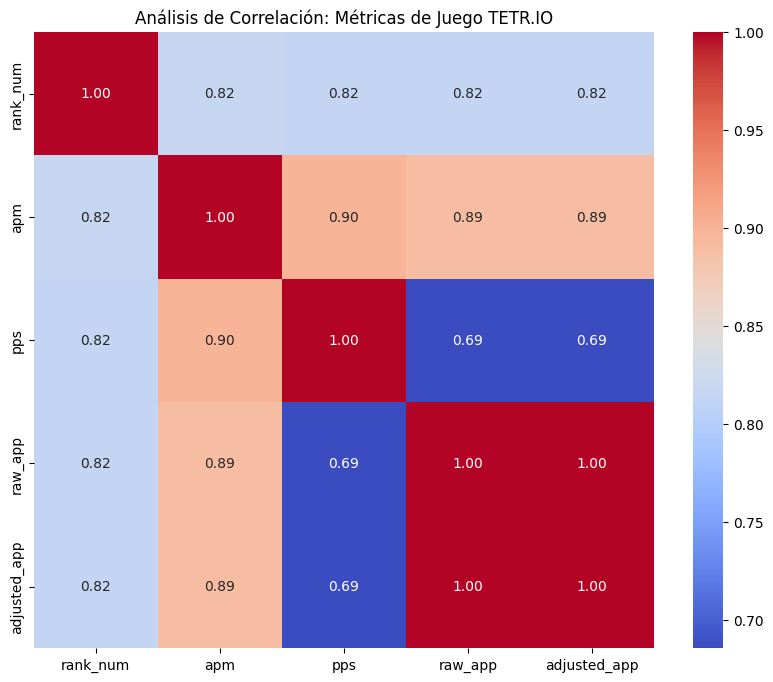

In [14]:
plt.figure(figsize=(10, 8))
# Usamos df_final porque ya está limpio y con los tipos de datos correctos
matriz_corr = df_final.corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis de Correlación: Métricas de Juego TETR.IO')
plt.show()

Para generar la matriz de correlación, primero transformamos los rangos categóricos (tlrank) en valores numéricos mediante un mapeo estratégico y limpiamos el dataset (df_clean) eliminando variables irrelevantes. Este proceso es fundamental porque los algoritmos estadísticos solo pueden procesar datos cuantitativos; sin esta conversión y limpieza de nulos, el mapa de calor resultaría vacío o erróneo. El objetivo final es visualizar y validar la intensidad de la relación entre métricas técnicas (como APM y PPS) y el rango del jugador, permitiendo identificar empíricamente qué habilidades mecánicas son las que realmente impulsan el ascenso en la competitividad de TETR.IO.

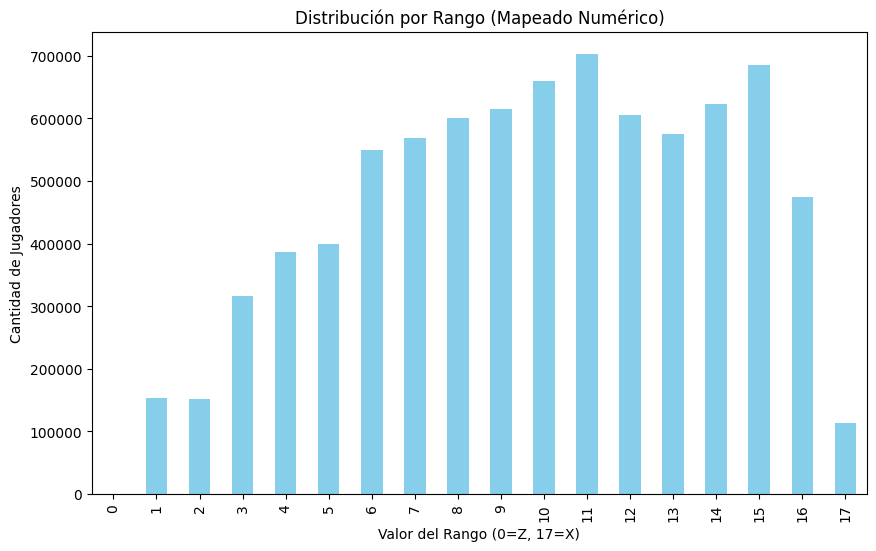

In [15]:
# GRÁFICO DE BARRAS (Distribución por Rango)
# Esto confirmará que el mapeo ya no es solo 0.0
plt.figure(figsize=(10, 6))
df_final['rank_num'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución por Rango (Mapeado Numérico)')
plt.xlabel('Valor del Rango (0=Z, 17=X)')
plt.ylabel('Cantidad de Jugadores')
plt.show()

Para generar esta visualización, aplicamos el método value_counts() sobre la variable mapeada rank_num y lo representamos mediante un gráfico de barras ordenado. Realizamos este paso para observar cómo se distribuye la población de jugadores a lo largo de los diferentes niveles de habilidad, permitiendo identificar si el dataset está balanceado o si existe una concentración excesiva en rangos específicos. Este análisis sirve para validar la integridad del mapeo realizado anteriormente y confirmar que la estructura de los datos es representativa y coherente antes de avanzar hacia el entrenamiento de modelos de Machine Learning.

/tmp/ipykernel_21009/3533817168.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")


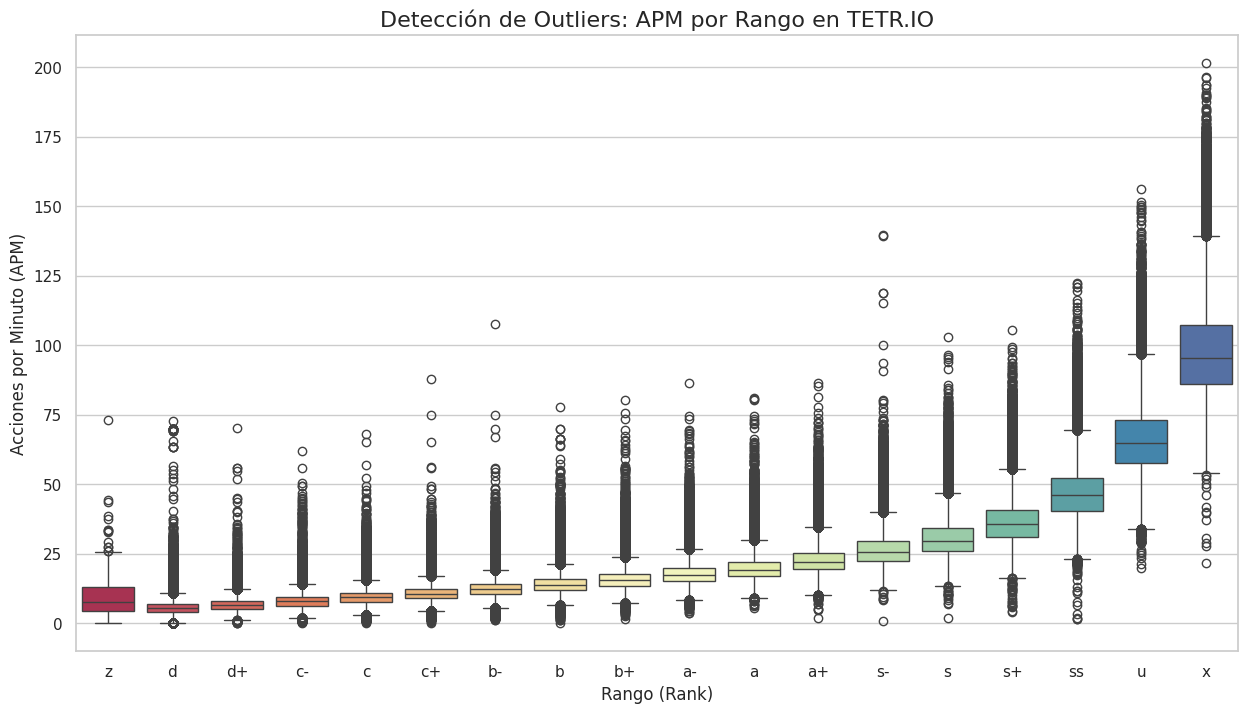

In [19]:
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Usamos tlrank en el eje X para ver las categorías de rango
# Ordenamos los rangos de menor a mayor para que el gráfico tenga sentido
orden_rangos = ['z', 'd', 'd+', 'c-', 'c', 'c+', 'b-', 'b', 'b+', 'a-', 'a', 'a+', 's-', 's', 's+', 'ss', 'u', 'x']

sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")

# 3. Personalización
plt.title('Detección de Outliers: APM por Rango en TETR.IO', fontsize=16)
plt.xlabel('Rango (Rank)', fontsize=12)
plt.ylabel('Acciones por Minuto (APM)', fontsize=12)

plt.show()

Los puntos fuera de los "bigotes" representan outliers o jugadores con un desempeño excepcional, como las smurfs que dominan mecánicamente rangos bajos. Técnicamente, estos valores se detectaron mediante el método de Rango Intercuartílico (IQR), un paso esencial para evitar que datos atípicos sesguen futuros modelos de aprendizaje automático. Aunque decidimos mantenerlos en este análisis para reflejar el límite de la habilidad humana en los eSports, en un modelo predictivo estándar lo ideal sería filtrarlos para garantizar resultados más equilibrados y precisos.